# The t-Distribution <hr style="border:2.5px solid #fce100"></hr>

<b> Norbert Francis C. Baylon </b>
<br>Computer Engineering Student
<br> Technological University of the Philippines Visayas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv(r"dataset\transformer-voltage-10-sample.csv",
                 delimiter = ",",
                 index_col=["Sample"])
df

,Voltage
Sample,
1,118.3
2,119.2
3,119.7
4,119.5
5,120.0
6,120.1
7,120.2
8,120.8
9,121.5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 1 to 10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  10 non-null     float64
dtypes: float64(1)
memory usage: 160.0 bytes


In [5]:
df.describe()

,Voltage
count,10.000000
mean,120.110000
std,1.050344
min,118.300000
25%,119.550000
50%,120.050000
75%,120.650000
max,121.800000


In [6]:
alpha = 0.01
n = df['Voltage'].count()

t_critical = stats.t.ppf(1-alpha/2,n-1)
t_critical

np.float64(3.2498355415921254)

In [8]:
n = df['Voltage'].count()
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

ci_lower, ci_upper = stats.t.interval(
    confidence = 0.95,
    df = n-1,
    loc = mean,
    scale = std/np.sqrt(n)
)

print(f"Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

Confidence Interval: [119.36, 120.86]


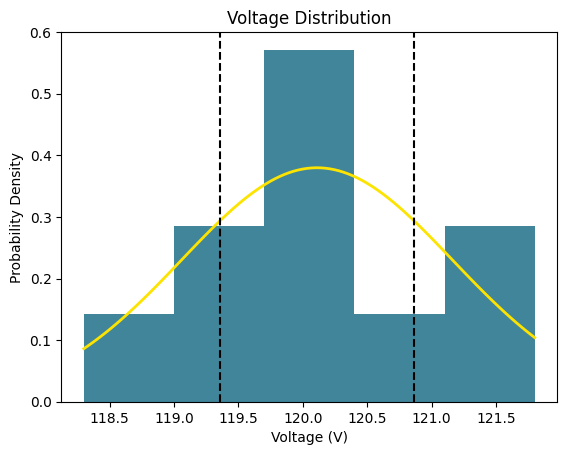

In [9]:
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

x = np.linspace(x_min,x_max,100)
p = stats.norm.pdf(x,mean,std)
plt.plot(x,p,
         linewidth = 2,
         color = '#fce300')

plt.hist(df['Voltage'],
         bins = 5,
         density = True,
         alpha = 0.8,
         color = '#126782')

plt.title('Voltage Distribution')
plt.ylabel('Probability Density')
plt.xlabel('Voltage (V)')

plt.axvline(x = ci_lower,
            color = 'black',
            linestyle = '--')

plt.axvline(x = ci_upper,
            color = 'black',
            linestyle = '--')

plt.show()

# Shoe Inventory

In [10]:
df = pd.read_csv(r"dataset\shoe-inventory.csv",
                 delimiter = ",")
df

,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10


In [12]:
df.shape

(17, 13)

In [14]:
mean_size_6 = df.iloc[0,1:13].mean()
mean_size_6

np.float64(2.9166666666666665)

In [15]:
std_size_6 = df.iloc[0,1:13].std()
std_size_6

np.float64(1.781640374554423)

In [24]:
mean = df.iloc[:17,1:13].mean(axis=1)
std = df.iloc[:17,1:13].std(axis=1)

df['ci_lower'], df['ci_upper'] = stats.t.interval(
    confidence = 0.95,
    df = n-1,
    loc = mean,
    scale = std/np.sqrt(n)
)

c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [19]:
df

,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,ci_lower,ci_upper
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0,1.642158,4.191175
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1,0.291214,3.042120
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0,0.161993,3.171340
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1,1.445660,4.887673
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6,3.895223,8.271444
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6,7.968960,13.531040
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10,13.954455,23.712212
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26,24.268440,36.398226
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20,18.866114,26.633886
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10,14.194099,20.972568


In [20]:
df['ci_lower'] = df['ci_lower'].fillna(0)
df['ci_upper'] = df['ci_upper'].fillna(0)

In [21]:
df['ci_lower'] = df['ci_lower'].astype(int).round()
df['ci_upper'] = df['ci_upper'].astype(int).round()

In [22]:
df[['Size','ci_upper']]

,Size,ci_upper
0,6.0,4
1,6.5,3
2,7.0,3
3,7.5,4
4,8.0,8
5,8.5,13
6,9.0,23
7,9.5,36
8,10.0,26
9,10.5,20
